# Analisis Temporal Dropout — Simulasi dan Visualisasi

Notebook ini menguji augmentasi **Temporal Dropout** dengan memanggil langsung kelas `TemporalDropout`.

**Cara kerja `TemporalDropout.__call__`:**
- Hitung panjang segment yang dihapus: $d = \lfloor T \times p_{\max} \times r \rfloor$, di mana $r \sim \mathcal{U}(0, 1)$
- Pilih titik awal segment secara acak: $\text{start} \sim \mathcal{U}[0,\, T - d]$
- Hapus frame $[\text{start},\, \text{start}+d)$ → sekuens output memiliki $T - d$ frame

| Cell | Konten |
|------|--------|
| 4 | Simulasi perhitungan Temporal Dropout dalam **5 epoch** |
| 5 | Visualisasi baseline vs hasil Temporal Dropout pada **5 epoch** |
| 6 | Visualisasi distribusi **Maximum Dropout Proportion** |

## 1. Setup

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 600,
    'savefig.bbox'     : 'tight',
})

SELECTED_ID = 'P1_S15_R1'
MAX_DP      = 0.2   # parameter default
N_EPOCHS    = 5

COLOR_BASELINE = '#2166AC'
EPOCH_COLORS   = ['#D6604D', '#E07B39', '#8B5E9E', '#2E8B57', '#C0392B']

print(f'max_dp   : {MAX_DP}')
print(f'N_EPOCHS : {N_EPOCHS}')

max_dp   : 0.2
N_EPOCHS : 5


## 2. Definisi Kelas `TemporalDropout`

In [2]:
class TemporalDropout(object):
    """
    Apply temporal dropout by randomly removing a contiguous segment of frames.

    Args:
        max_dp (float): Maximum dropout proportion. Actual dropout length
            is between [0, vid_len * max_dp].
    """

    def __init__(self, max_dp=0.2) -> None:
        self.max_dp = max_dp

    def __call__(self, skeleton, **kwargs):
        vid_len = len(skeleton)
        dp_len  = int(vid_len * self.max_dp * np.random.random())
        start   = np.random.randint(0, vid_len - dp_len + 1)
        end     = start + dp_len
        index   = list(range(0, start)) + list(range(end, vid_len))
        return skeleton[index]


tdrop = TemporalDropout(max_dp=MAX_DP)
print(f'TemporalDropout dibuat: max_dp = {tdrop.max_dp}')
print()
print('Catatan penting:')
print('  dp_len = int(T × max_dp × r),  r ~ U(0,1)  →  dp_len ∈ [0, T×max_dp]')
print('  start  ~ randint[0, T - dp_len]')
print('  Segment [start, start+dp_len) dihapus → output shape: (T - dp_len, K, C)')
print('  Dropout bersifat KONTINU (satu blok), bukan frame acak tersebar')

TemporalDropout dibuat: max_dp = 0.2

Catatan penting:
  dp_len = int(T × max_dp × r),  r ~ U(0,1)  →  dp_len ∈ [0, T×max_dp]
  start  ~ randint[0, T - dp_len]
  Segment [start, start+dp_len) dihapus → output shape: (T - dp_len, K, C)
  Dropout bersifat KONTINU (satu blok), bukan frame acak tersebar


## 3. Load Data

In [3]:
with open('../data/pickle/pose_bisindo.pkl', 'rb') as f:
    dataset = pickle.load(f)

assert SELECTED_ID in dataset, f'{SELECTED_ID} tidak ditemukan.'

kp_data  = dataset[SELECTED_ID]['keypoints']  # (T, 86, 2)
skeleton = kp_data.copy()
T        = len(skeleton)

print(f'Video  : {SELECTED_ID}')
print(f'Shape  : {skeleton.shape}  →  T={T} frame, K=86 keypoint, C=2 koordinat')
print(f'Max dropout length (dp_len maks): int({T} × {MAX_DP}) = {int(T * MAX_DP)} frame')

Video  : P1_S15_R1
Shape  : (115, 86, 2)  →  T=115 frame, K=86 keypoint, C=2 koordinat
Max dropout length (dp_len maks): int(115 × 0.2) = 23 frame


## 4. Simulasi Perhitungan — 5 Epoch

Setiap epoch: nilai $r$, `dp_len`, `start`, `end` berbeda-beda secara acak.

In [4]:
np.random.seed(7)

epoch_results = []   # list of dict per epoch

print('SIMULASI: Temporal Dropout pada 5 Epoch')
print('=' * 100)
print(f'Video: {SELECTED_ID}  |  T = {T} frame  |  max_dp = {MAX_DP}')
print(f'Formula: dp_len = int(T × max_dp × r),  r ~ U(0,1)')
print('=' * 100)
header = (
    f"{'Epoch':<8}"
    f"{'r ~ U(0,1)':<14}"
    f"{'dp_len (frame dihapus)':<26}"
    f"{'start':<10}"
    f"{'end':<10}"
    f"{'Segment dihapus':<22}"
    f"{'T output':<12}"
    f"Proporsi dihapus"
)
print(header)
print('-' * 100)

for ep in range(1, N_EPOCHS + 1):
    # Replikasi logika __call__ secara eksplisit untuk logging
    r      = np.random.random()
    dp_len = int(T * MAX_DP * r)
    start  = np.random.randint(0, T - dp_len + 1)
    end    = start + dp_len
    index  = list(range(0, start)) + list(range(end, T))
    result = skeleton[index]
    prop   = dp_len / T

    epoch_results.append({
        'epoch'   : ep,
        'r'       : r,
        'dp_len'  : dp_len,
        'start'   : start,
        'end'     : end,
        'T_out'   : len(result),
        'prop'    : prop,
        'result'  : result,
    })

    print(
        f"{ep:<8}"
        f"{r:.4f}{'':8}"
        f"int({T}×{MAX_DP}×{r:.4f}) = {dp_len}{'':6}"
        f"{start:<10}"
        f"{end:<10}"
        f"[{start}, {end}){'':8}"
        f"{len(result):<12}"
        f"{prop*100:.1f}%"
    )

print('=' * 100)
print()
print('→ dp_len berbeda tiap epoch karena r di-sample ulang')
print('→ Segment yang dihapus KONTINU (satu blok berurutan)')
print('→ T output = T - dp_len (sekuens lebih pendek)')

SIMULASI: Temporal Dropout pada 5 Epoch
Video: P1_S15_R1  |  T = 115 frame  |  max_dp = 0.2
Formula: dp_len = int(T × max_dp × r),  r ~ U(0,1)
Epoch   r ~ U(0,1)    dp_len (frame dihapus)    start     end       Segment dihapus       T output    Proporsi dihapus
----------------------------------------------------------------------------------------------------
1       0.0763        int(115×0.2×0.0763) = 1      25        26        [25, 26)        114         0.9%
2       0.3190        int(115×0.2×0.3190) = 7      83        90        [83, 90)        108         6.1%
3       0.7235        int(115×0.2×0.7235) = 16      92        108       [92, 108)        99          13.9%
4       0.3080        int(115×0.2×0.3080) = 7      23        30        [23, 30)        108         6.1%
5       0.5011        int(115×0.2×0.5011) = 11      42        53        [42, 53)        104         9.6%

→ dp_len berbeda tiap epoch karena r di-sample ulang
→ Segment yang dihapus KONTINU (satu blok berurutan)
→ T ou

## 5. Visualisasi — Baseline vs Temporal Dropout pada 5 Epoch

Setiap baris menampilkan **timeline frame** sebagai bar horizontal.  
- Biru = frame yang **dipertahankan**  
- Merah = frame yang **dihapus** (dropout segment)

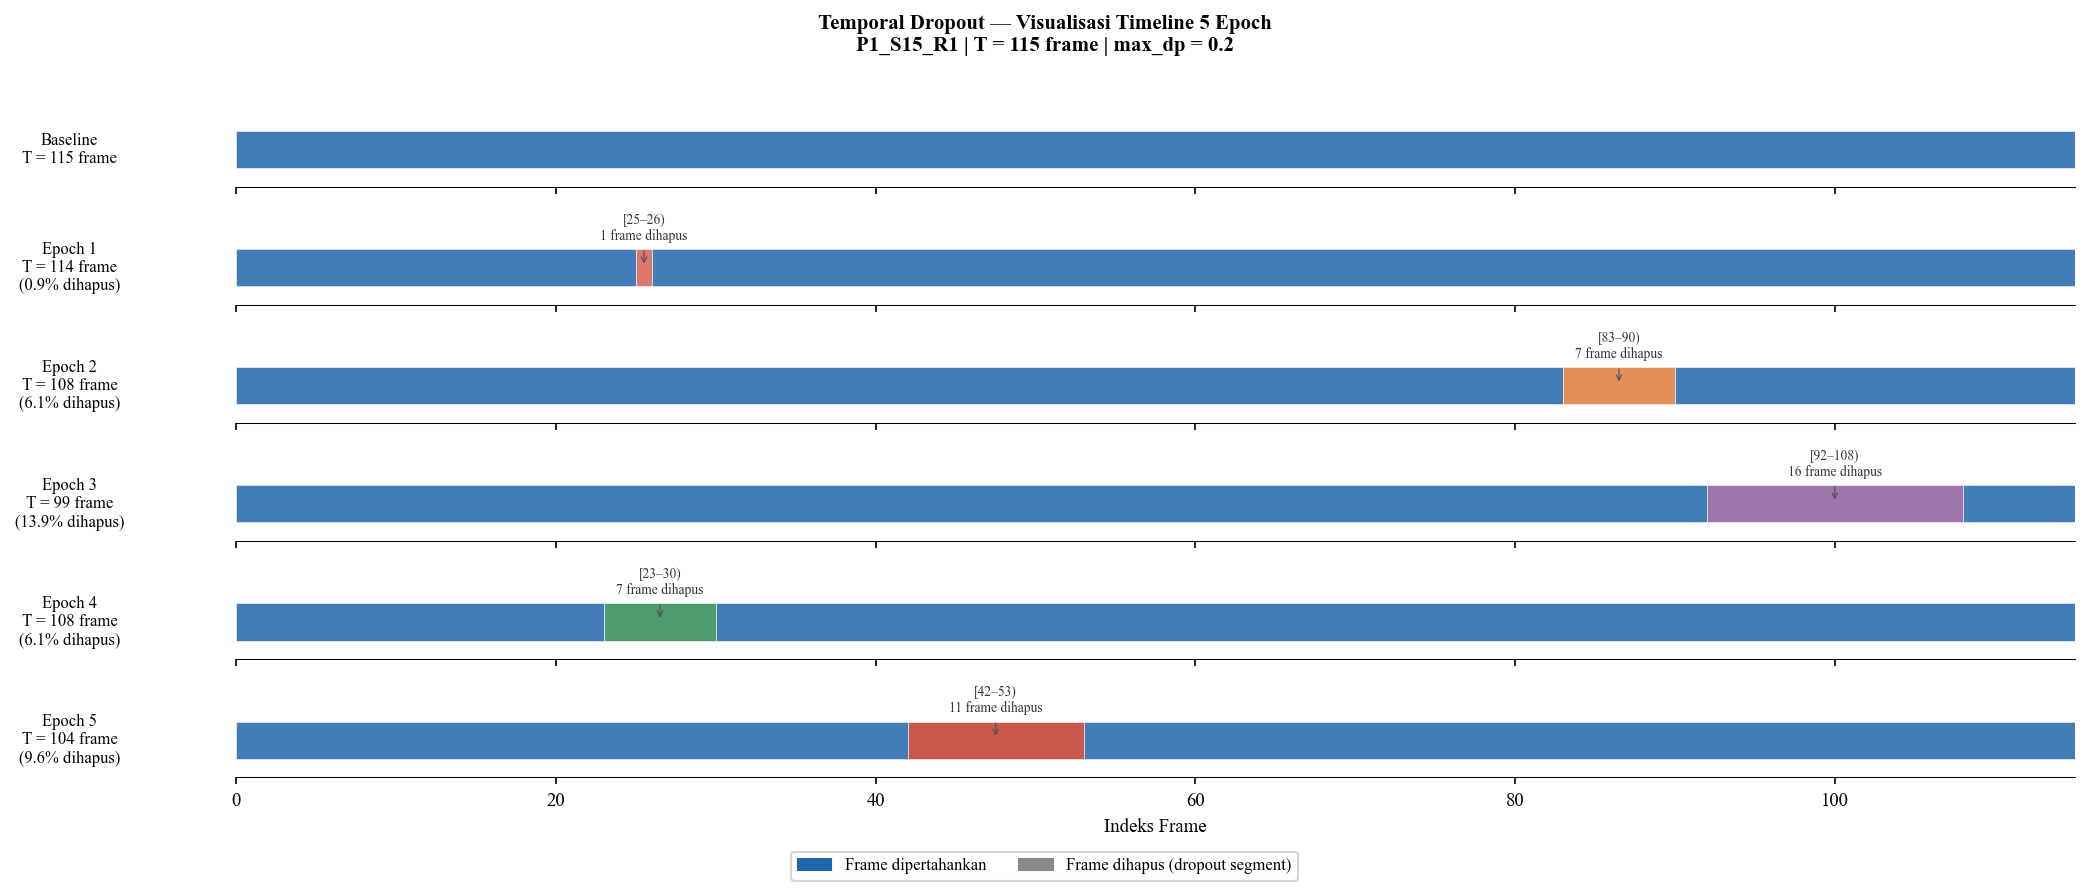

Saved: docs/temporal_dropout_timeline.png


In [5]:
fig, axes = plt.subplots(N_EPOCHS + 1, 1, figsize=(14, 5.5), sharex=True)

def draw_timeline(ax, T_total, start_drop, end_drop, color_drop, label, dp_len):
    """
    Gambar timeline frame sebagai bar horizontal.
    Frame yang dipertahankan = biru, frame yang dihapus = warna epoch.
    """
    # Frame dipertahankan (sebelum segment)
    if start_drop > 0:
        ax.barh(0, start_drop, left=0, height=0.5,
                color=COLOR_BASELINE, alpha=0.85, edgecolor='white', lw=0.3)
    # Frame dihapus
    if dp_len > 0:
        ax.barh(0, dp_len, left=start_drop, height=0.5,
                color=color_drop, alpha=0.85, edgecolor='white', lw=0.3)
    # Frame dipertahankan (sesudah segment)
    if end_drop < T_total:
        ax.barh(0, T_total - end_drop, left=end_drop, height=0.5,
                color=COLOR_BASELINE, alpha=0.85, edgecolor='white', lw=0.3)

    ax.set_xlim(0, T_total)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=80, va='center')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Anotasi segment yang dihapus
    if dp_len > 0:
        mid = start_drop + dp_len / 2
        ax.annotate(
            f'[{start_drop}–{end_drop})\n{dp_len} frame dihapus',
            xy=(mid, 0), xytext=(mid, 0.38),
            fontsize=6.5, ha='center', color='#333',
            arrowprops=dict(arrowstyle='->', color='#555', lw=0.6)
        )

# ── Baris 0: Baseline ─────────────────────────────────────────
draw_timeline(
    axes[0], T,
    start_drop=0, end_drop=0,
    color_drop=COLOR_BASELINE,
    label=f'Baseline\nT = {T} frame',
    dp_len=0
)

# ── Baris 1–5: Epoch 1–5 ──────────────────────────────────────
for res, ep_color in zip(epoch_results, EPOCH_COLORS):
    ep    = res['epoch']
    T_out = res['T_out']
    draw_timeline(
        axes[ep], T,
        start_drop=res['start'],
        end_drop=res['end'],
        color_drop=ep_color,
        label=(
            f'Epoch {ep}\n'
            f'T = {T_out} frame\n'
            f'({res["prop"]*100:.1f}% dihapus)'
        ),
        dp_len=res['dp_len']
    )

axes[-1].set_xlabel('Indeks Frame', fontsize=9)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_BASELINE, label='Frame dipertahankan'),
        mpatches.Patch(color='#888888',      label='Frame dihapus (dropout segment)'),
    ],
    loc='lower center', ncol=2, fontsize=8,
    frameon=True, bbox_to_anchor=(0.5, -0.04)
)
fig.suptitle(
    f'Temporal Dropout — Visualisasi Timeline 5 Epoch\n'
    f'{SELECTED_ID} | T = {T} frame | max_dp = {MAX_DP}',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/temporal_dropout_timeline.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/temporal_dropout_timeline.png')

## 6. Visualisasi Distribusi Maximum Dropout Proportion

Tiga subplot:
- **(a)** Distribusi `dp_len` aktual (dalam frame) dari banyak simulasi
- **(b)** Distribusi proporsi dropout aktual $d/T$ — menunjukkan rentang $[0, p_{\max}]$
- **(c)** Perbandingan distribusi `dp_len` untuk berbagai nilai `max_dp`

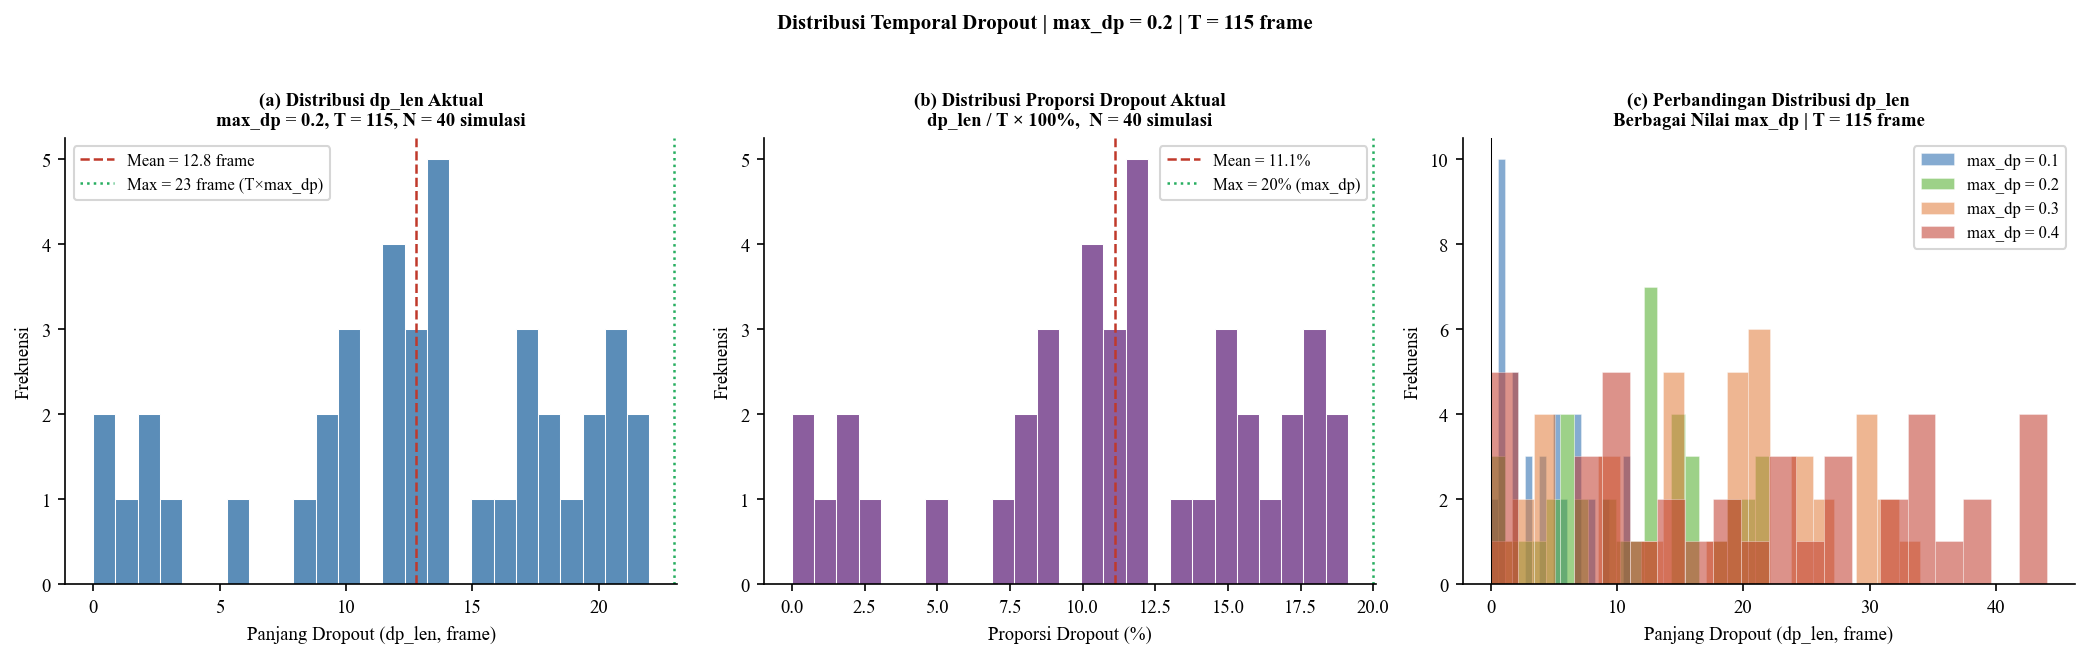

Saved: docs/temporal_dropout_distribusi.png


In [6]:
N_SIM = 40
np.random.seed(0)

# Simulasi N_SIM epoch dengan max_dp default
sim_dp_len  = np.array([int(T * MAX_DP * np.random.random()) for _ in range(N_SIM)])
sim_prop    = sim_dp_len / T

# Simulasi untuk berbagai max_dp
max_dp_vals  = [0.1, 0.2, 0.3, 0.4]
sim_by_maxdp = {
    mdp: np.array([int(T * mdp * np.random.random()) for _ in range(N_SIM)])
    for mdp in max_dp_vals
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# ── (a) Distribusi dp_len dalam frame ─────────────────────────
ax = axes[0]
ax.hist(sim_dp_len, bins=25, color='#5B8DB8', edgecolor='white', lw=0.5)
ax.axvline(sim_dp_len.mean(), color='#C0392B', lw=1.2, ls='--',
           label=f'Mean = {sim_dp_len.mean():.1f} frame')
ax.axvline(int(T * MAX_DP), color='#27AE60', lw=1.2, ls=':',
           label=f'Max = {int(T * MAX_DP)} frame (T×max_dp)')
ax.set_xlabel('Panjang Dropout (dp_len, frame)', fontsize=9)
ax.set_ylabel('Frekuensi', fontsize=9)
ax.set_title(
    f'(a) Distribusi dp_len Aktual\n'
    f'max_dp = {MAX_DP}, T = {T}, N = {N_SIM:,} simulasi',
    fontsize=9
)
ax.legend(fontsize=8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ── (b) Distribusi proporsi dropout ───────────────────────────
ax2 = axes[1]
ax2.hist(sim_prop * 100, bins=25, color='#8B5E9E', edgecolor='white', lw=0.5)
ax2.axvline(sim_prop.mean() * 100, color='#C0392B', lw=1.2, ls='--',
            label=f'Mean = {sim_prop.mean()*100:.1f}%')
ax2.axvline(MAX_DP * 100, color='#27AE60', lw=1.2, ls=':',
            label=f'Max = {MAX_DP*100:.0f}% (max_dp)')
ax2.set_xlabel('Proporsi Dropout (%)', fontsize=9)
ax2.set_ylabel('Frekuensi', fontsize=9)
ax2.set_title(
    f'(b) Distribusi Proporsi Dropout Aktual\n'
    f'dp_len / T × 100%,  N = {N_SIM:,} simulasi',
    fontsize=9
)
ax2.legend(fontsize=8)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# ── (c) Perbandingan berbagai max_dp ──────────────────────────
ax3 = axes[2]
colors_mdp = ['#2166AC', '#4DAC26', '#E07B39', '#C0392B']
for mdp, col in zip(max_dp_vals, colors_mdp):
    vals = sim_by_maxdp[mdp]
    ax3.hist(vals, bins=20, alpha=0.55, color=col, edgecolor='white',
             lw=0.3, label=f'max_dp = {mdp}')
ax3.axvline(0, color='black', lw=0.5, ls='-')
ax3.set_xlabel('Panjang Dropout (dp_len, frame)', fontsize=9)
ax3.set_ylabel('Frekuensi', fontsize=9)
ax3.set_title(
    f'(c) Perbandingan Distribusi dp_len\nBerbagai Nilai max_dp | T = {T} frame',
    fontsize=9
)
ax3.legend(fontsize=8)
for spine in ['top', 'right']:
    ax3.spines[spine].set_visible(False)

fig.suptitle(
    f'Distribusi Temporal Dropout | max_dp = {MAX_DP} | T = {T} frame',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('docs/temporal_dropout_distribusi.png', dpi=600, bbox_inches='tight')
plt.show()
print('Saved: docs/temporal_dropout_distribusi.png')